In [1]:
from activation_funcs import *
from error_funcs import *
from initializer import *
from optimizer import *

from Model import MyModel
from layers import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
mnist = np.load("mnist.npz")
x_train, y_train = mnist['x_train'], mnist['y_train']
x_test, y_test = mnist['x_test'], mnist['y_test']

In [3]:
epoch = 10

In [4]:
def one_hot_encoding(label, max_num=10):
    tmp = [0 for i in range(max_num)]
    tmp[int(label)] = 1
    return tmp

def one_hot_decoding(label):
    return label.index(1)

In [5]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = np.array([one_hot_encoding(i) for i in y_train])

In [6]:
affine_model = MyModel()

affine_model.add_layer(Flatten())
affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
affine_model.add_layer(Softmax())

affine_model.set_loss_func(func=CrossEntropyError())

In [7]:
affine_model.load_data(data_kind='train', x=x_train, y=y_train)
affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [8]:
affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.8163 | Accuracy: 0.7844
start epoch 2
Epoch 2 | Loss: 0.3401 | Accuracy: 0.9027
start epoch 3
Epoch 3 | Loss: 0.2798 | Accuracy: 0.9195
start epoch 4
Epoch 4 | Loss: 0.2451 | Accuracy: 0.9299
start epoch 5
Epoch 5 | Loss: 0.2199 | Accuracy: 0.9374
start epoch 6
Epoch 6 | Loss: 0.2001 | Accuracy: 0.9430
start epoch 7
Epoch 7 | Loss: 0.1838 | Accuracy: 0.9479
start epoch 8
Epoch 8 | Loss: 0.1701 | Accuracy: 0.9522
start epoch 9
Epoch 9 | Loss: 0.1584 | Accuracy: 0.9553
start epoch 10
Epoch 10 | Loss: 0.1482 | Accuracy: 0.9579


In [9]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9533


In [10]:
test_affine_model = MyModel()

test_affine_model.add_layer(Flatten())
test_affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.15))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.10))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.05))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
test_affine_model.add_layer(Softmax())

test_affine_model.set_loss_func(func=CrossEntropyError())

In [11]:
test_affine_model.load_data(data_kind='train', x=x_train, y=y_train)
test_affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
test_affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [12]:
test_affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.3694 | Accuracy: 0.8924
start epoch 2
Epoch 2 | Loss: 0.1601 | Accuracy: 0.9534
start epoch 3
Epoch 3 | Loss: 0.1145 | Accuracy: 0.9668
start epoch 4
Epoch 4 | Loss: 0.0882 | Accuracy: 0.9746
start epoch 5
Epoch 5 | Loss: 0.0707 | Accuracy: 0.9802
start epoch 6
Epoch 6 | Loss: 0.0578 | Accuracy: 0.9844
start epoch 7
Epoch 7 | Loss: 0.0475 | Accuracy: 0.9872
start epoch 8
Epoch 8 | Loss: 0.0392 | Accuracy: 0.9896
start epoch 9
Epoch 9 | Loss: 0.0322 | Accuracy: 0.9917
start epoch 10
Epoch 10 | Loss: 0.0267 | Accuracy: 0.9940


In [13]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = test_affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9763


In [14]:
# cnn_model = MyModel()

# cnn_model.add_layer(Conv(filter_num=10, filter_channels=1, filter_height=5, filter_width=5, stride=1, pad=0, learning_rate=0.01))
# cnn_model.add_layer(Relu())
# cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0))
# cnn_model.add_layer(Flatten())
# cnn_model.add_layer(Affine(input_size=1440, output_size=50, learning_rate=0.01))
# cnn_model.add_layer(Relu())
# cnn_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
# cnn_model.add_layer(Softmax())

# cnn_model.set_loss_func(func=CrossEntropyError())

In [15]:
cnn_model = MyModel()

cnn_model.add_layer(Conv(filter_num=10, filter_channels=1, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.01)) # 28x28 
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 14x14 -> (N, C, H, W) = (batch, 10, 14, 14)
cnn_model.add_layer(Conv(filter_num=10, filter_channels=10, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.01)) # 14x14
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 7x7 -> (N, C, H, W) = (batch, 10, 7, 7)
cnn_model.add_layer(Flatten())
cnn_model.add_layer(Affine(input_size=490, output_size=50, learning_rate=0.01)) # 10*7x7=490
cnn_model.add_layer(Relu())
cnn_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
cnn_model.add_layer(Softmax())

cnn_model.set_loss_func(func=CrossEntropyError())

In [16]:
x_train_cnn = x_train.reshape(-1, 1, 28, 28)
x_test_cnn = x_test.reshape(-1, 1, 28, 28)
cnn_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
cnn_model.data_batch_setting(setting_data='x_train', batch_size=100)
cnn_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [17]:
cnn_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.7035 | Accuracy: 0.7838
start epoch 2
Epoch 2 | Loss: 0.2780 | Accuracy: 0.9155
start epoch 3
Epoch 3 | Loss: 0.2110 | Accuracy: 0.9357
start epoch 4
Epoch 4 | Loss: 0.1736 | Accuracy: 0.9478
start epoch 5
Epoch 5 | Loss: 0.1492 | Accuracy: 0.9554
start epoch 6
Epoch 6 | Loss: 0.1319 | Accuracy: 0.9603
start epoch 7
Epoch 7 | Loss: 0.1192 | Accuracy: 0.9645
start epoch 8
Epoch 8 | Loss: 0.1093 | Accuracy: 0.9673
start epoch 9
Epoch 9 | Loss: 0.1013 | Accuracy: 0.9696
start epoch 10
Epoch 10 | Loss: 0.0948 | Accuracy: 0.9714


In [18]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = cnn_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9709


In [19]:
resnet_model = MyModel()

resnet_model.add_layer(Conv(filter_num=10, filter_channels=1, filter_height=3, filter_width=3))
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock(10, 3, 3))
resnet_model.add_layer(ResidualBlock(10, 3, 3))
resnet_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0))
resnet_model.add_layer(Flatten())
resnet_model.add_layer(Affine(input_size=1690, output_size=10)) # 사이즈 연산 과정은 아래 주석 참고
resnet_model.add_layer(Softmax())

resnet_model.set_loss_func(func=CrossEntropyError())

In [20]:
resnet_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [21]:
resnet_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.3202 | Accuracy: 0.9051
start epoch 2
Epoch 2 | Loss: 0.1195 | Accuracy: 0.9657
start epoch 3
Epoch 3 | Loss: 0.0869 | Accuracy: 0.9750
start epoch 4
Epoch 4 | Loss: 0.0724 | Accuracy: 0.9787
start epoch 5
Epoch 5 | Loss: 0.0636 | Accuracy: 0.9811
start epoch 6
Epoch 6 | Loss: 0.0576 | Accuracy: 0.9828
start epoch 7
Epoch 7 | Loss: 0.0530 | Accuracy: 0.9843
start epoch 8
Epoch 8 | Loss: 0.0493 | Accuracy: 0.9853
start epoch 9
Epoch 9 | Loss: 0.0463 | Accuracy: 0.9861
start epoch 10
Epoch 10 | Loss: 0.0437 | Accuracy: 0.9870


In [22]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9837


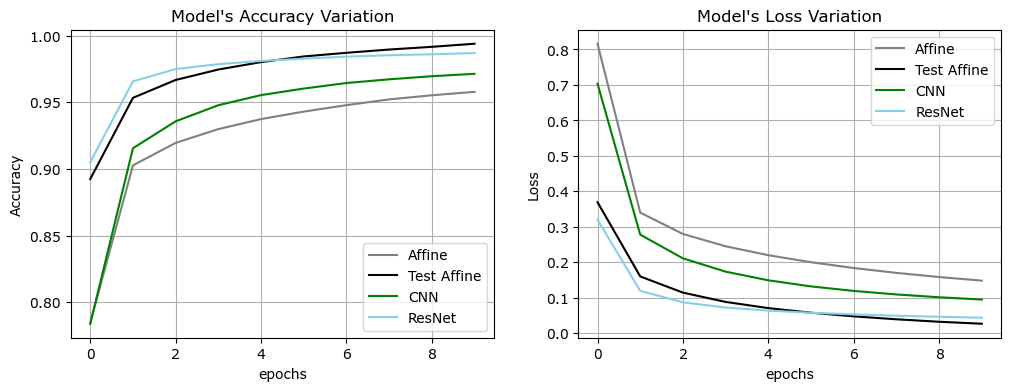

In [27]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot([i for i in range(epoch)], affine_model.acc_log, label='Affine', color='gray')
ax1.plot([i for i in range(epoch)], test_affine_model.acc_log, label='Test Affine', color='black')
ax1.plot([i for i in range(epoch)], cnn_model.acc_log, label='CNN', color='green')
ax1.plot([i for i in range(epoch)], resnet_model.acc_log, label='ResNet', color='skyblue')
ax1.set_title("Model's Accuracy Variation")
ax1.set_xlabel("epochs")
ax1.set_ylabel("Accuracy")
ax1.grid()
ax1.legend()

ax2.plot([i for i in range(epoch)], affine_model.loss_log, label='Affine', color='gray')
ax2.plot([i for i in range(epoch)], test_affine_model.loss_log, label='Test Affine', color='black')
ax2.plot([i for i in range(epoch)], cnn_model.loss_log, label='CNN', color='green')
ax2.plot([i for i in range(epoch)], resnet_model.loss_log, label='ResNet', color='skyblue')
ax2.set_title("Model's Loss Variation")
ax2.set_xlabel("epochs")
ax2.set_ylabel("Loss")
ax2.grid()
ax2.legend()

plt.show()